# Problem 1: Convolutional Neural Network

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


# Intro

We will be tackling a straightforward image classification task using the CIFAR-10 dataset. Our goal is to build a CNN model that can accurately classify the images into their respective categories.


# 0. Warm-up

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.Tensor``.

For vision, PyTorch has a package called ``torchvision``,
that has data loaders for common datasets such as Imagenet, CIFAR10, MNIST, etc. and data transformers for images, viz., ``torchvision.datasets``
and ``torch.utils.data.DataLoader``.
This provides a huge convenience and avoids writing boilerplate code.

In [4]:
%matplotlib inline

# Numerical Operations
import math
import numpy as np

# Reading/Writing Data
import pandas as pd
import os
import csv

# For Progress Bar
from tqdm import tqdm

# Pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from matplotlib import cm

## MNIST Dataset

The built-in datasets library in the package `torchvision` will automatically download some dataset if you set `download=True` when initializing the dataset.

In [5]:
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True,
                                transform=transforms.ToTensor())
mnist_testset = datasets.MNIST(root='./data', train=False, download=True,
                               transform=transforms.ToTensor())
print("Print the training dataset:\n ", mnist_trainset)
print("Print the testing dataset:\n ", mnist_testset)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.15MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 449kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.51MB/s]

Print the training dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Print the testing dataset:
  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


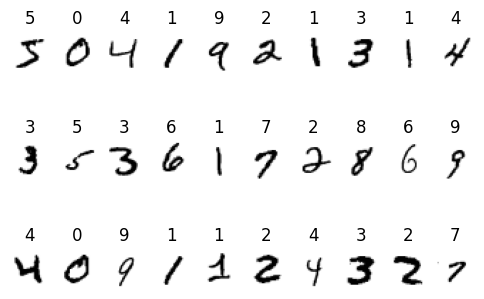

In [7]:
fig, axs = plt.subplots(3, 10, figsize = (6, 4))
plt.gray()

# loop through subplots and add mnist images
for i, ax in enumerate(axs.flat):
  ax.imshow(mnist_trainset[i][0][0], cmap=cm.gray_r)
  ax.axis('off')
  ax.set_title('{}'.format(mnist_trainset[i][1]))

In [8]:
train_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_testset, batch_size=1, shuffle=False)
print(train_loader)
print(test_loader)

for batch_id, (data, label) in enumerate(train_loader):
  print('batch_id:', batch_id)
  print(data.shape)
  print(label.shape)
  break

batch_id: 0
torch.Size([4, 1, 28, 28])
torch.Size([4])


## CIFAR-10 Dataset

Follow the above instructions on MNIST dataset, write code to load and visualize the CIFAR-10 dataset in the similar manner.

CIFAR-10 dataset has the classes (listed below): ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’, ‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of size $3 \times 32 \times 32$, i.e. 3-channel color images of $32 \times 32$ pixels in size.

<!-- <h4>Note:</h4>
The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range [-1, 1].

1.   List item
2.   List item -->



In [9]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
           'ship', 'truck')

cifar_trainset = datasets.CIFAR10(root='./data', train=True, download=True,
                                transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='./data', train=False, download=True,
                               transform=transforms.ToTensor())
print("Print the training dataset:\n ", cifar_trainset)
print("Print the testing dataset:\n ", cifar_testset)

train_loader = torch.utils.data.DataLoader(cifar_trainset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_testset, batch_size=1, shuffle=False)

100%|██████████| 170M/170M [00:17<00:00, 10.0MB/s] 


Print the training dataset:
  Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Print the testing dataset:
  Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


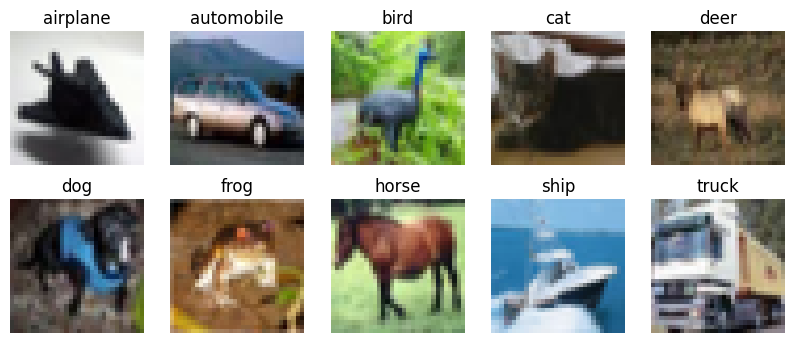

In [10]:
# visualize the different classes of the cifar dataset

def cifar_imshow(img):
  npimg = img.numpy()
  return np.transpose(npimg, (1, 2, 0)) # reorganize the channel

# mapping from numeric label to class label
label_map = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

# for each class in the cifar dataset, load one image and display it in a 2 x 5 subplot
fig, axs = plt.subplots(2, 5, figsize = (10, 4))

for i in range(10):
  ax = axs[i // 5, i % 5]
  idx = next(idx for idx, label in enumerate(cifar_trainset.targets) if label == i)
  img, label = cifar_trainset[idx]
  ax.imshow(cifar_imshow(img))
  ax.axis('off')
  ax.set_title(label_map[label])

In [11]:
# print out dimensions of a sample batch from the cifar10 dataset
for batch_id, (data, label) in enumerate(train_loader):
  print('batch_id:', batch_id)
  print(data.shape)
  print(label.shape)
  break

batch_id: 0
torch.Size([4, 3, 32, 32])
torch.Size([4])


# 1-a. Define Convolutional Neural Network

---





In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## CNN Model

Reading before implementation:
1. Official documentation: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html, make sure that you understand what are x,y,z in nn.Conv2d(x,y,z) representing individually.
2. Additional Animation on Convolution: https://towardsdatascience.com/conv2d-to-finally-understand-what-happens-in-the-forward-pass-1bbaafb0b148.

This is a very standard CNN pytorch model, the layers are already defined for you, in constrat with the `nn.Sequential()` method we taught in tutorial, we will be using another way to define our model:

In [13]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Read through official documentation: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        # and make sure you understand the concept of 2D convolution and Conv2d layer's definition
        # Here is also some cool animation: https://towardsdatascience.com/conv2d-to-finally-understand-what-happens-in-the-forward-pass-1bbaafb0b148
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)

        # TODO: replace the xxx and yyy with proper numbers
        output_dim_after_conv = 16 * 5 * 5
        output_dim_after_fc = 10
        #

        self.fc1 = nn.Linear(output_dim_after_conv, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, output_dim_after_fc)

    def forward(self, x):
        # TODO: build your forward function
        # 1. First pass the x through the first conv layer followed by relu then pooling
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        # 2. Then pass the output of step 1 through the second conv layer follewed by relu then pooling
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        # 3. (important) Since we are now moving onto fully connected layer, we need to flatten the tensor,
        # 3. use `x = torch.flatten(x, 1)` with the output from step 2
        x = torch.flatten(x, 1)
        # 4 Finally pass the output of step 3 into `fc1`, `fc2` and `fc3 (remember the relu! Hint: look up F.relu)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)

        # ENDS HERE
        return x

my_cnn = Net().to(device)  # operate on GPU

After finishing the TODO in `forward()` try to run the next code block.
```
Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=output_dim_after_conv, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=output_dim_after_fc, bias=True)
)
```
You should get the exact same output as above with `print(my_cnn)`, with the values you've defined for output_dim_after_conv and output_dim_after_fc.

In [14]:
print(my_cnn)

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


## Training Loop

Define your training loop, it should looks very similiar (almost the same) to what you did for MLP in hw2:

In [ ]:
def trainer(train_loader, valid_loader, model, config, device):

    criterion = nn.CrossEntropyLoss(reduction='mean')
    optimizer = torch.optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.7)

    if not os.path.isdir('./models'):
        os.mkdir('./models') # Create directory of saving models.

    n_epochs, best_loss, step, early_stop_count = config['n_epochs'], math.inf, 0, 0

    # TODO: Compute and return these metrics as in HW2 P3
    train_loss_epoch_history = []
    train_acc_history = []
    valid_loss_history = []
    valid_acc_history = []

    for epoch in range(n_epochs):
        model.train() # Set your model to train mode.
        train_loss_record = []
        train_acc_record = []

        # tqdm is a package to visualize your training progress.
        train_pbar = tqdm(train_loader, position=0, leave=True)

        for x, y in train_pbar:
            optimizer.zero_grad()               # Set gradient to zero.
            x, y = x.to(device), y.to(device)   # Move your data to device.

            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()                     # Compute gradient(backpropagation).
            optimizer.step()                    # Update parameters.
            step += 1

            train_loss_record.append(loss.detach().item())
            train_acc_record.append((pred.argmax(dim=1) == y).sum().item() / y.size(0))
            # Display current epoch number and loss on tqdm progress bar.
            train_pbar.set_description(f'Epoch [{epoch+1}/{n_epochs}]')
            train_pbar.set_postfix({'loss': loss.detach().item()})

        mean_train_loss = sum(train_loss_record)/len(train_loss_record)
        mean_train_acc = sum(train_acc_record)/len(train_acc_record)

        model.eval() # Set your model to evaluation mode.
        valid_loss_record = []
        valid_acc_record = []
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                pred = model(x)
                loss = criterion(pred, y)

                _, predicted = torch.max(pred.data, 1)
                valid_acc_record.append((predicted == y).sum().item() / predicted.size(0))
            valid_loss_record.append(loss.item())
        mean_valid_acc = sum(valid_acc_record)/len(valid_acc_record)
        mean_valid_loss = sum(valid_loss_record)/len(valid_loss_record)

        train_loss_epoch_history.append(mean_train_loss)
        train_acc_history.append(mean_train_acc)
        valid_loss_history.append(mean_valid_loss)
        valid_acc_history.append(mean_valid_acc)

    return train_loss_epoch_history, train_acc_history, valid_loss_history, valid_acc_history


In [20]:
config = { # do not modified
    'seed': 5201314,      # Your seed number, you can pick your lucky number. :)
    'valid_ratio': 0.2,   # validation_size = train_size * valid_ratio
    'n_epochs': 250,      # Number of epochs.
    'batch_size': 256,
    'learning_rate': 0.01,
    'early_stop': 25,    # If model has not improved for this many consecutive epochs, stop training.
    'save_path': './models/model.ckpt'  # Your model will be saved here.
}

In [21]:
cifar_train_data, cifar_valid_data = random_split(cifar_trainset, [1-config['valid_ratio'], config['valid_ratio']])

train_loader = torch.utils.data.DataLoader(cifar_train_data, batch_size=config['batch_size'], shuffle=True)
valid_loader = torch.utils.data.DataLoader(cifar_valid_data, batch_size=config['batch_size'], shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_testset, batch_size=config['batch_size'], shuffle=False)

In [22]:
train_loss_epoch_history, train_acc_history, valid_loss_history, valid_acc_history = trainer(train_loader, valid_loader, my_cnn, config, device)

Epoch [250/250]: 100%|██████████| 157/157 [00:05<00:00, 28.82it/s, loss=0.00155]


## Evaluation on CIFAR-10 Testing

Getting overall accuracy

In [23]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = my_cnn(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 57 %


Getting class-wise accuracies

In [24]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# TODO: calculate and print accuracy separately for each class
# Report percentage accuracy to 1 decimal place, e.g. 80.1%
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = my_cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f}%')

Accuracy for class: plane is 64.0%
Accuracy for class: car   is 70.7%
Accuracy for class: bird  is 48.4%
Accuracy for class: cat   is 37.9%
Accuracy for class: deer  is 50.1%
Accuracy for class: dog   is 46.6%
Accuracy for class: frog  is 63.9%
Accuracy for class: horse is 60.4%
Accuracy for class: ship  is 72.2%
Accuracy for class: truck is 63.4%


# 1-b. Learning Curves

Plot two plots of the CNN model:
1. the learning curve (error versus epoch)
2. the accuracy curve (validation accuracy versus epoch)

Plot training metrics in blue and validation metrics in orange for both plots. Use the code template provided.

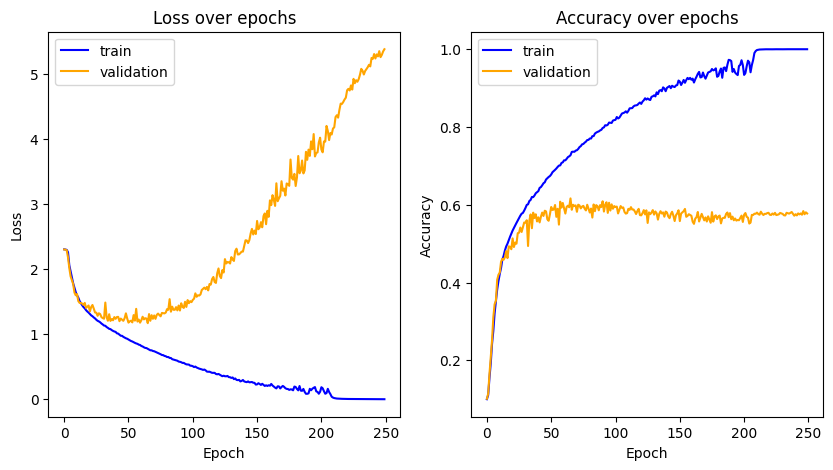

In [25]:
# TODO 1-b

# extract training loss vector
train_loss = train_loss_epoch_history

# extract validation loss vector
valid_loss = valid_loss_history

# extract training acc vector
train_acc = train_acc_history

# extract validation acc vector
valid_acc = valid_acc_history

# create 1x2 subplots for loss on left, accuracy on right
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# plot train in blue, val in orange
axs[0].plot(train_loss, label='train', color='blue')
axs[0].plot(valid_loss, label='validation', color='orange')
axs[0].set_title('Loss over epochs')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# plot train in blue, val in orange
axs[1].plot(train_acc, label='train', color='blue')
axs[1].plot(valid_acc, label='validation', color='orange')
axs[1].set_title('Accuracy over epochs')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

# ENDS HERE

# 1-c. Try Different CNN Parameters
Try different CNN parameters/configurations/model architectures to see if you can reach 80\% accuracy on the CIFAR-10 testing set. Please briefly explain what you change and include the screenshot of model info (using `print(model)`) in the pdf.

In [ ]:
# TODO 1-c
class your_cnn(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2,2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

your_cnn = your_cnn().to(device)

your_config = {
    'seed': 5201314,
    'valid_ratio': 0.2,
    'n_epochs': 80,
    'batch_size': 128,
    'learning_rate': 0.01,
    'early_stop': 15,
    'save_path': './models/your_model.ckpt'
}
# ENDS HERE

In [ ]:
train_loss_epoch_history, train_acc_history, valid_loss_history, valid_acc_history = trainer(train_loader, valid_loader, your_cnn, your_config, device)

# 1-d, e, f, g Hand-Written Questions

In [ ]:
# Answer them in the pdf